In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
data = pd.read_csv("../data/processed/customer_features.csv")

In [3]:
data.head()

,CustomerID,recency_days,purchase_frequency,historical_revenue,total_quantity,unique_products,customer_tenure_days,average_order_value,avg_quantity_per_order,orders_per_month,revenue_90d,revenue_30d,previous_90d_revenue,spending_trend,future_revenue,country
0,12346,133,1,77183.60,74215,1,133,77183.600000,74215.000000,0.184049,0.00,0.0,77183.60,-77183.60,0.00,United Kingdom
1,12347,54,3,1823.43,1117,63,175,607.810000,372.333333,0.439024,636.25,0.0,1187.18,-550.93,2486.57,Iceland
2,12348,56,3,1487.24,2124,22,166,495.746667,708.000000,0.459184,367.00,0.0,1120.24,-753.24,310.00,Finland
3,12350,118,1,334.40,197,17,118,334.400000,197.000000,0.202703,0.00,0.0,334.40,-334.40,0.00,Norway
4,12352,70,5,1561.81,254,26,104,312.362000,50.800000,1.119403,280.66,0.0,1281.15,-1000.49,944.23,Norway


In [4]:
data.shape

(2718, 16)

In [5]:
data.isnull().sum()

CustomerID                0
recency_days              0
purchase_frequency        0
historical_revenue        0
total_quantity            0
unique_products           0
customer_tenure_days      0
average_order_value       0
avg_quantity_per_order    0
orders_per_month          0
revenue_90d               0
revenue_30d               0
previous_90d_revenue      0
spending_trend            0
future_revenue            0
country                   0
dtype: int64

In [6]:
data.describe()

,CustomerID,recency_days,purchase_frequency,historical_revenue,total_quantity,unique_products,customer_tenure_days,average_order_value,avg_quantity_per_order,orders_per_month,revenue_90d,revenue_30d,previous_90d_revenue,spending_trend,future_revenue
count,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000,2718.000000
mean,15293.879323,62.974614,2.725901,1226.119191,714.242458,41.693157,111.428256,407.739942,244.877487,0.572389,625.819287,247.101141,565.828595,59.990692,1591.332145
std,1715.705215,52.394210,4.025443,4122.445975,2784.885240,54.396999,54.760426,1554.951049,1453.628635,0.601192,1985.340759,975.063242,2438.503369,1798.337437,7752.651724
min,12346.000000,0.000000,1.000000,2.900000,1.000000,1.000000,0.000000,2.900000,1.000000,0.142180,0.000000,0.000000,0.000000,-77183.600000,0.000000
25%,13819.500000,19.000000,1.000000,242.717500,115.000000,12.000000,68.000000,172.235000,83.000000,0.267857,0.000000,0.000000,0.000000,-242.570000,0.000000
50%,15242.500000,49.000000,2.000000,476.115000,258.500000,26.000000,117.000000,291.940000,143.666667,0.428571,270.575000,0.000000,166.770000,54.930000,419.275000
75%,16767.750000,96.000000,3.000000,1070.040000,592.750000,53.000000,168.000000,422.645000,250.875000,0.697674,593.727500,288.422500,508.080000,333.577500,1291.767500
max,18287.000000,181.000000,86.000000,110713.120000,78758.000000,881.000000,181.000000,77183.600000,74215.000000,12.227488,52847.100000,28408.140000,77183.600000,14462.180000,195015.190000


In [17]:
np.median(data["future_revenue"])
data[data["future_revenue"] > 419]

,CustomerID,recency_days,purchase_frequency,historical_revenue,total_quantity,unique_products,customer_tenure_days,average_order_value,avg_quantity_per_order,orders_per_month,revenue_90d,revenue_30d,previous_90d_revenue,spending_trend,future_revenue,country
1,12347,54,3,1823.43,1117,63,175,607.810,372.333333,0.439024,636.25,0.00,1187.18,-550.93,2486.57,Iceland
4,12352,70,5,1561.81,254,26,104,312.362,50.800000,1.119403,280.66,0.00,1281.15,-1000.49,944.23,Norway
9,12359,113,2,2386.41,609,93,139,1193.205,304.500000,0.355030,0.00,0.00,2386.41,-2386.41,3986.17,Cyprus
10,12360,8,1,1083.58,434,45,8,1083.580,434.000000,0.789474,1083.58,1083.58,0.00,1083.58,1578.48,Austria
12,12362,33,2,974.34,504,52,103,487.170,252.000000,0.451128,495.24,0.00,479.10,16.14,4251.89,Belgium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2709,18260,13,5,2216.07,1301,79,166,443.214,260.200000,0.765306,1428.30,427.97,787.77,640.53,427.13,United Kingdom
2710,18263,60,1,307.60,328,15,60,307.600,328.000000,0.333333,307.60,0.00,0.00,307.60,905.56,United Kingdom
2713,18272,33,2,980.54,788,47,54,490.270,394.000000,0.714286,980.54,0.00,0.00,980.54,2098.04,United Kingdom
2716,18283,8,5,535.05,336,142,145,107.010,67.200000,0.857143,217.15,99.47,317.90,-100.75,1559.83,United Kingdom


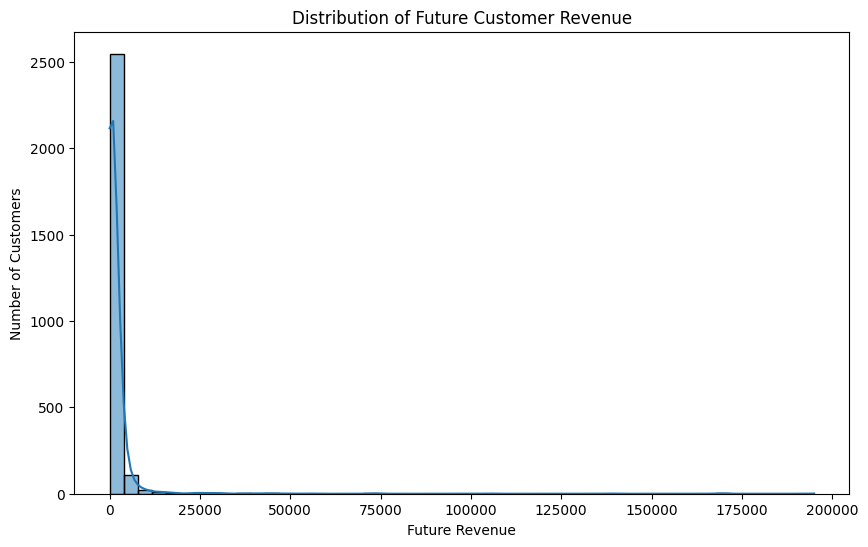

In [8]:
# Target Distribution 
plt.figure(figsize=(10, 6))

sns.histplot(
    data["future_revenue"],
    bins=50,
    kde=True
)

plt.title("Distribution of Future Customer Revenue")
plt.xlabel("Future Revenue")
plt.ylabel("Number of Customers")
plt.show()

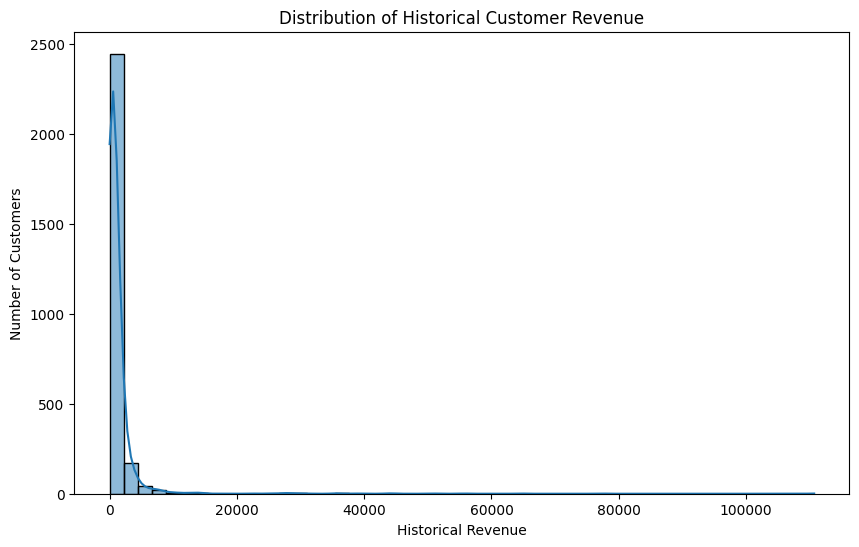

In [19]:
# Historical Revenue Distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    data["historical_revenue"],
    bins=50,
    kde=True
)

plt.title("Distribution of Historical Customer Revenue")
plt.xlabel("Historical Revenue")
plt.ylabel("Number of Customers")
plt.show()

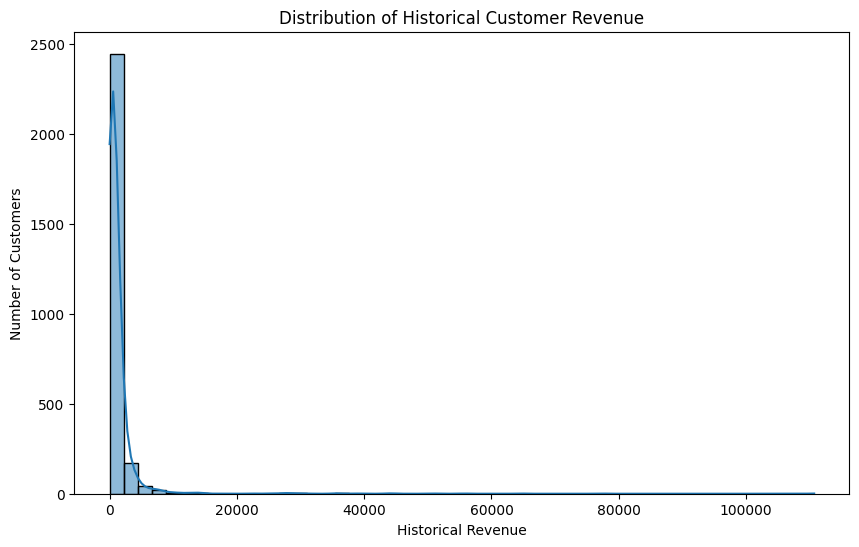

In [21]:
# Recency Distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    data["historical_revenue"],
    bins=50,
    kde=True
)

plt.title("Distribution of Historical Customer Revenue")
plt.xlabel("Historical Revenue")
plt.ylabel("Number of Customers")
plt.show()

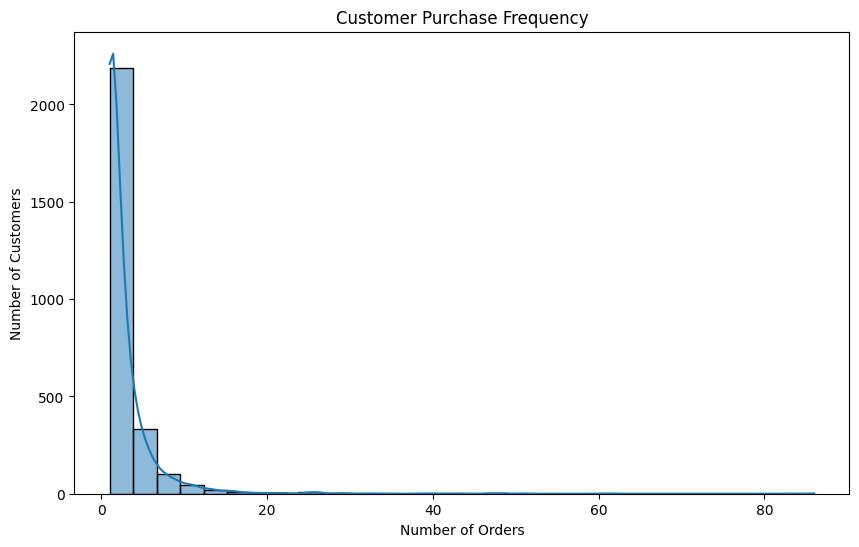

In [22]:
# Purchase Frequency 
plt.figure(figsize=(10, 6))

sns.histplot(
    data["purchase_frequency"],
    bins=30,
    kde=True
)

plt.title("Customer Purchase Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.show()

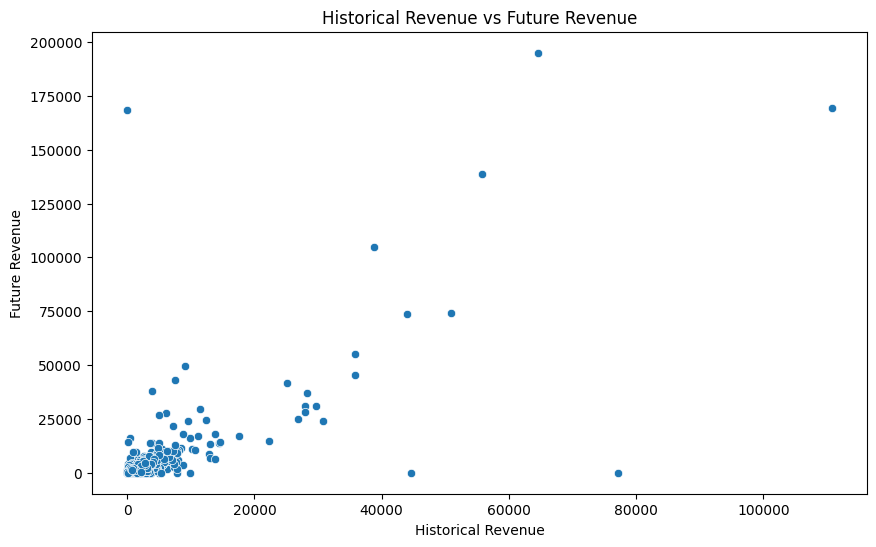

In [23]:
# Future Revenue vs Historical Revenue
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="historical_revenue",
    y="future_revenue"
)

plt.title("Historical Revenue vs Future Revenue")
plt.xlabel("Historical Revenue")
plt.ylabel("Future Revenue")
plt.show()

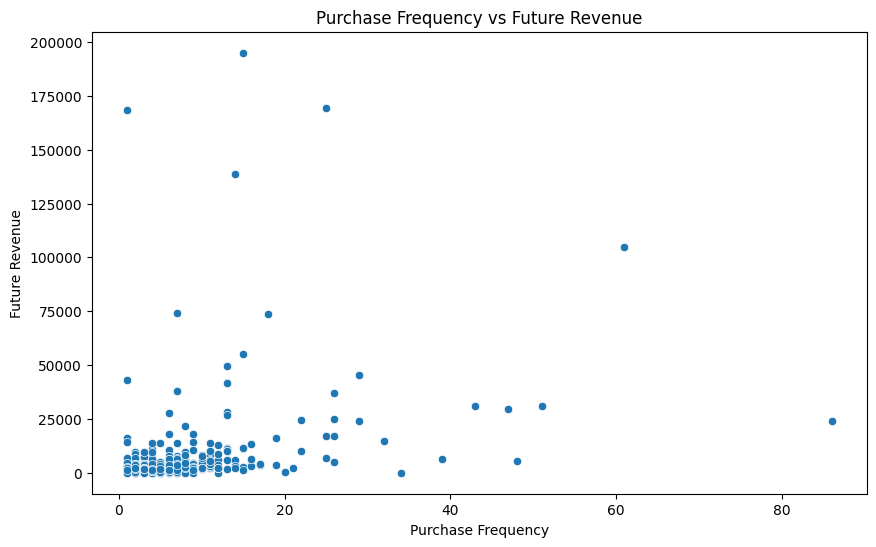

In [24]:
# Frequency vs Future Revenue 
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="purchase_frequency",
    y="future_revenue"
)

plt.title("Purchase Frequency vs Future Revenue")
plt.xlabel("Purchase Frequency")
plt.ylabel("Future Revenue")
plt.show()

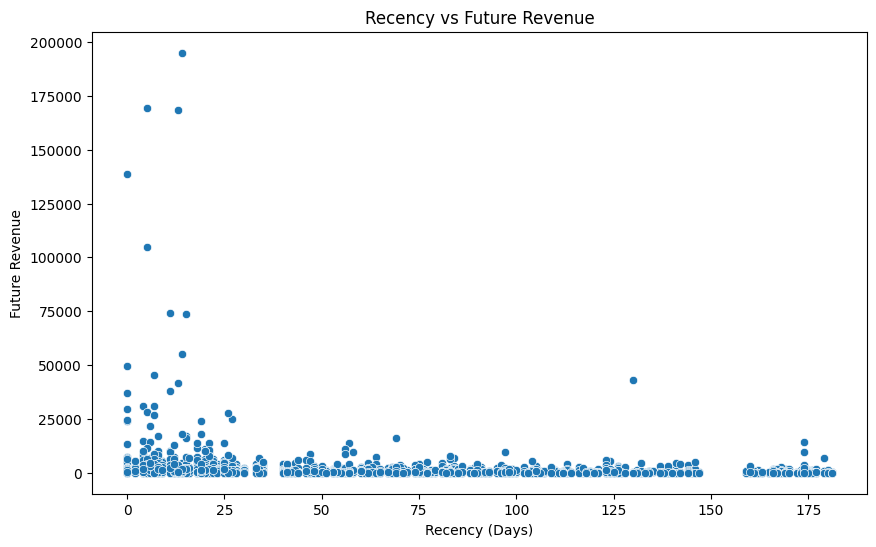

In [25]:
# recency vs Future Revenue 
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="recency_days",
    y="future_revenue"
)

plt.title("Recency vs Future Revenue")
plt.xlabel("Recency (Days)")
plt.ylabel("Future Revenue")
plt.show()

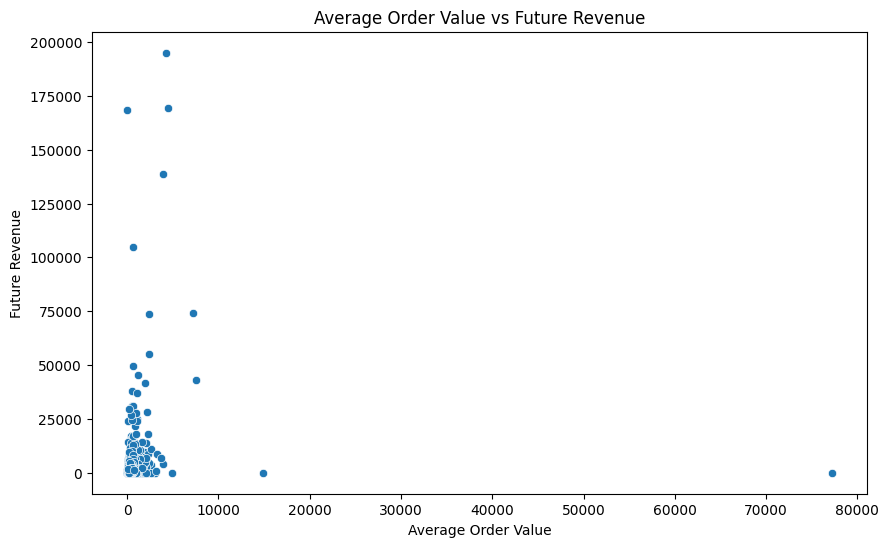

In [26]:
# Average Order Value vs Future Revenue 
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="average_order_value",
    y="future_revenue"
)

plt.title("Average Order Value vs Future Revenue")
plt.xlabel("Average Order Value")
plt.ylabel("Future Revenue")
plt.show()

In [27]:
numeric_cols = [
    "recency_days",
    "purchase_frequency",
    "historical_revenue",
    "average_order_value",
    "total_quantity",
    "avg_quantity_per_order",
    "unique_products",
    "customer_tenure_days",
    "orders_per_month",
    "revenue_30d",
    "revenue_90d",
    "spending_trend",
    "future_revenue"
]

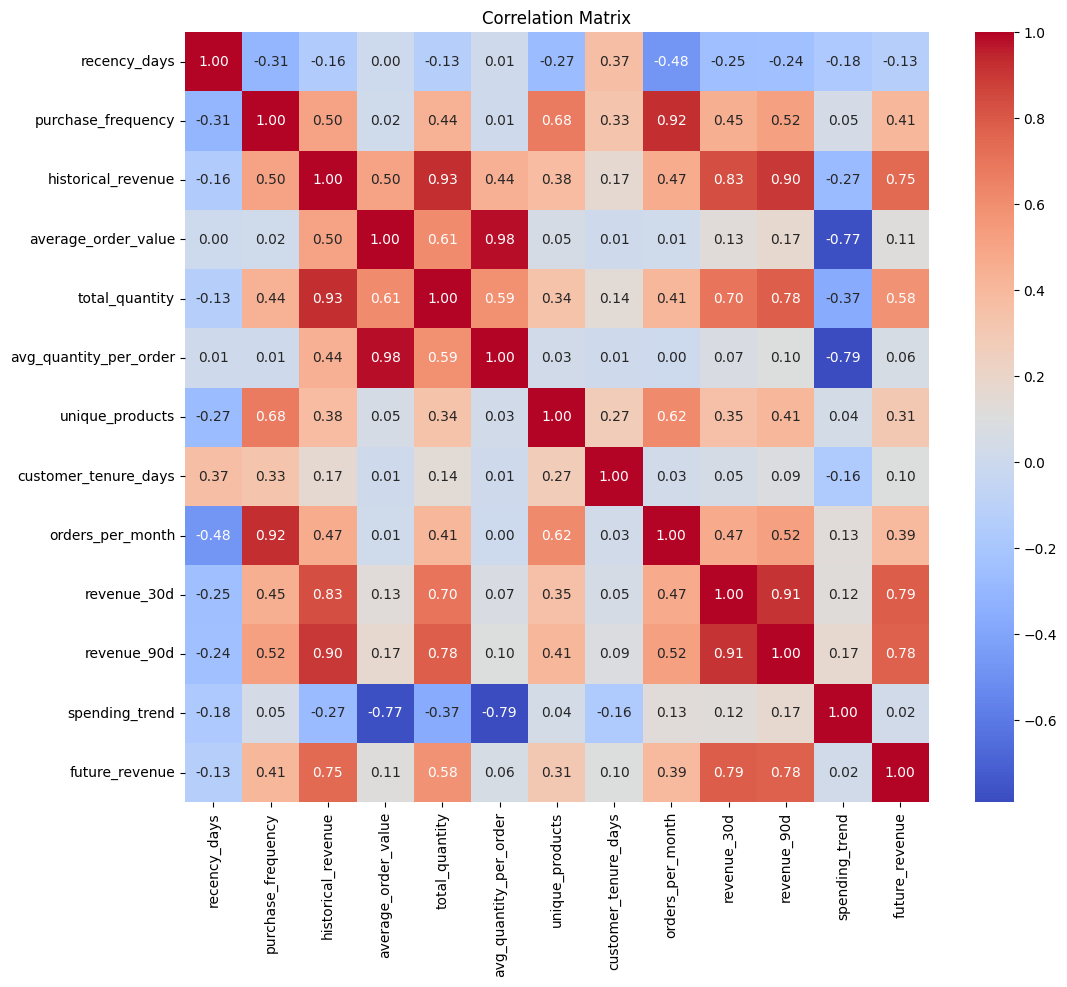

In [28]:
corr = data[numeric_cols].corr()
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [29]:
# order_per_month strongly related with purchase_frequency 

In [31]:
zero_future = (
    data["future_revenue"] == 0
).sum()

print(zero_future)

791


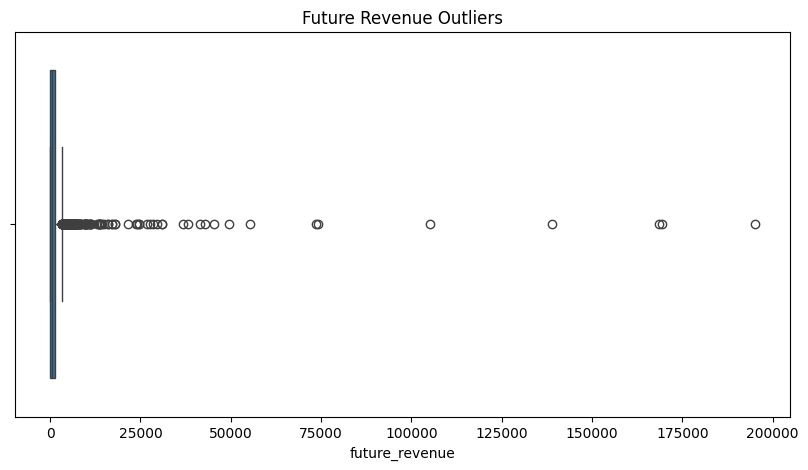

In [32]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=data["future_revenue"]
)

plt.title("Future Revenue Outliers")
plt.show()

In [34]:
# Checked for skewed data 
data["log_future_revenue"] = np.log1p(
    data["future_revenue"]
)

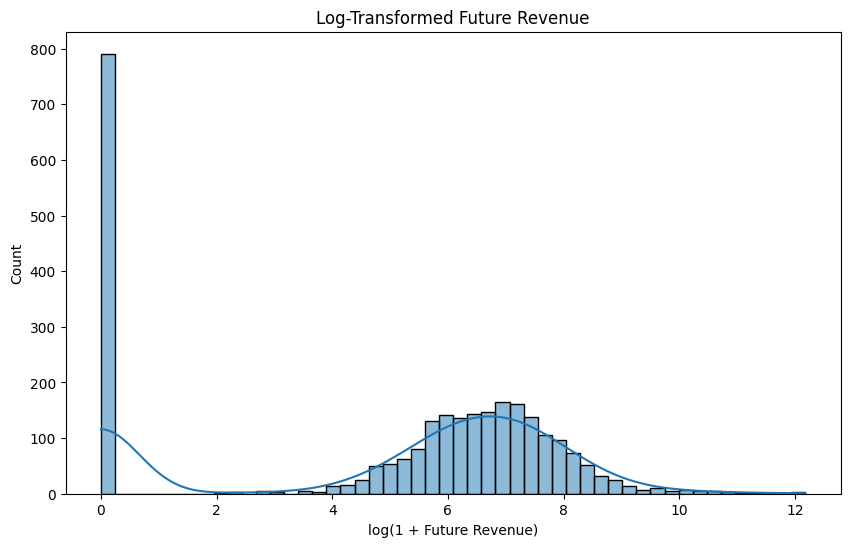

In [35]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data["log_future_revenue"],
    bins=50,
    kde=True
    
)

plt.title("Log-Transformed Future Revenue")
plt.xlabel("log(1 + Future Revenue)")
plt.show()

### Key Findings

1. Customer revenue is highly/right skewed.
2. A relatively small group of customers contributes a large amount of revenue.
3. Purchase frequency shows a relationship with future revenue.
4. Historical spending appears to provide useful information about future spending.
5. Recency appears to be an important behavioral variable.
6. Some features are strongly correlated with each other.
7. Future revenue contains a number of zero-value observations.
8. Some extreme revenue values require careful treatment rather than automatic removal.